In [2]:
import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import logit

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts

# Time-series
from prophet import Prophet          # uncomment if installed
from pmdarima import auto_arima      # uncomment if installed

#Geo (optional — comment out if geopandas not installed)
import geopandas as gpd
import folium

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})


In [3]:
import pandas as pd
df = pd.read_csv("df_clean.csv")

In [4]:
df.columns.to_list()

['facility',
 'date_notified',
 'year',
 'month',
 'fy',
 'district',
 'bact_confirmed',
 'tb_type',
 'site_of_disease',
 'drug_sensitivity',
 'tb_category',
 'xpert_result',
 'date_xpert_collected',
 'xpert_rifampicin',
 'date_xpert_result',
 'smear_result',
 'date_smear_result',
 'dnt',
 'who_category',
 'mwrd',
 'dst_result',
 'culture_result',
 'tb_lam_test',
 'tb_lam_result',
 'hiv_status',
 'hiv_history',
 'on_cotrimoxazole',
 'date_cotrimoxazole_start',
 'on_art',
 'date_art_start',
 'sex',
 'dob',
 'age',
 'age_cat',
 'age_group',
 'hrg_cat',
 'hrg',
 'referred_by',
 'contact_tb_pos',
 'contact_mdr_tb',
 'diabetic',
 'health_worker',
 'chw',
 'miner',
 'prisoners',
 'refugee',
 'transit_rehab',
 'cdt_diagnosis',
 'cdt_origin',
 'weight_start_kg',
 'height_cm',
 'date_treatment_start',
 'bmi_cat_start',
 'bmi_start',
 'treatment_regimen',
 'chw_followup',
 'nutrition_support',
 'control_m2',
 'date_control_m2',
 'control_m5',
 'date_control_m5',
 'control_end',
 'date_control_en

# ════════════════════════════════════════════════════════════════════════════════
# CELL 8.1 — High‑Risk Group Analysis
# ════════════════════════════════════════════════════════════════════════════════


SECTION 8.1 — HIGH‑RISK GROUP ANALYSIS

▶ Prevalence of High‑Risk Factors:


,Risk Factor,Count,% of Total Cases
0,Prisoner,1304,15.3
3,HIV Positive,1165,13.6
4,TB Household Contact,747,8.7
2,Refugee,100,1.2
1,Miner,91,1.1
5,Malnourished,0,0.0


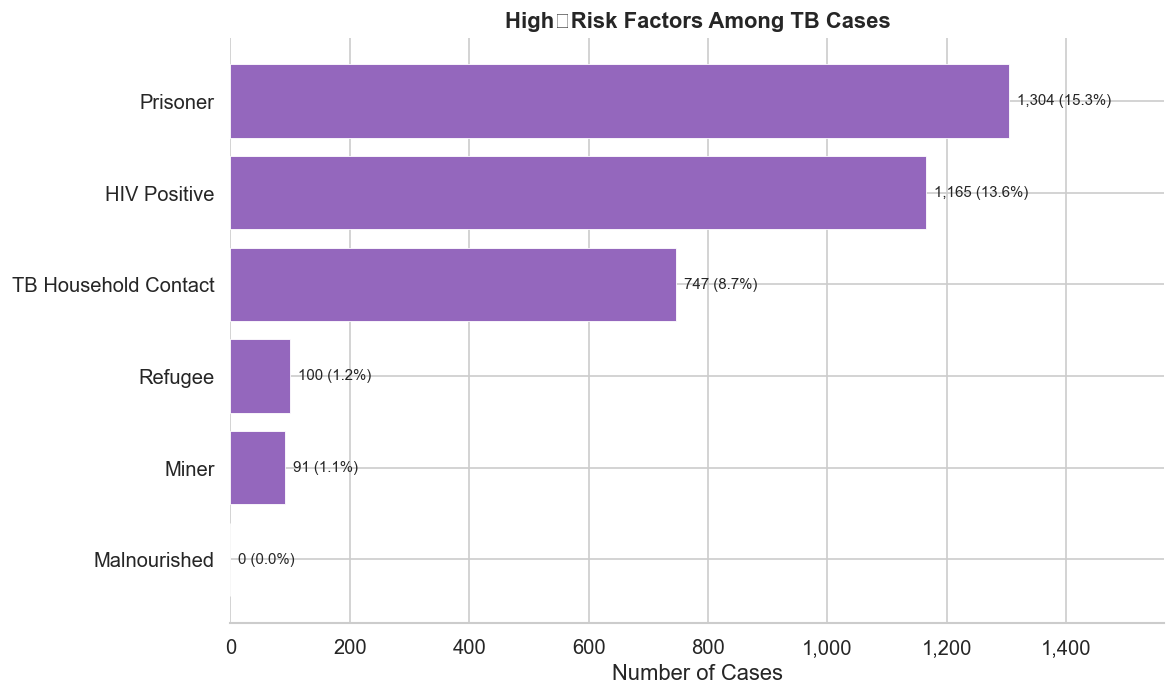


▶ Overall treatment success rate: 30.9% (2,636 / 8,540)
▶ Prisoner group (n=1,304): treatment success = 36.8%
   (higher than overall by 5.9 pp)
▶ Miner group (n=91): treatment success = 27.5%
   (lower than overall by 3.4 pp)
▶ Refugee group (n=100): treatment success = 30.0%
   (lower than overall by 0.9 pp)
▶ HIV Positive group (n=1,165): treatment success = 26.1%
   (lower than overall by 4.8 pp)
▶ TB Household Contact group (n=747): treatment success = 43.2%
   (higher than overall by 12.3 pp)
▶ No Malnourished cases identified.


In [6]:
print("SECTION 8.1 — HIGH‑RISK GROUP ANALYSIS")

# Define colors
PURPLE = "#9467bd"

# Map risk factors to column names and conditions (using actual columns)
risk_mapping = {
    'Prisoner': ('prisoners', None),
    'Miner': ('miner', None),
    'Refugee': ('refugee', None),
    'HIV Positive': ('hiv_pos', None),
    'TB Household Contact': ('contact_tb_pos', None),
    'Malnourished': ('bmi_cat_start', lambda x: str(x).lower() == 'underweight')
}

# Collect risk factor counts
risk_data = []
for risk, (col, condition) in risk_mapping.items():
    if col in df.columns:
        if condition is None:
            # Binary numeric column (0/1)
            if pd.api.types.is_numeric_dtype(df[col]):
                count = df[col].sum()
            else:
                count = (df[col].astype(str).str.lower().str.contains('yes|1|true', na=False)).sum()
        else:
            count = df[col].apply(condition).sum()
        risk_data.append({
            'Risk Factor': risk,
            'Count': count,
            '% of Total Cases': (count / len(df) * 100).round(1)
        })
    else:
        print(f"⚠️ Column '{col}' not found – skipping {risk}.")

if risk_data:
    risk_df = pd.DataFrame(risk_data).sort_values('Count', ascending=False)
    print("\n▶ Prevalence of High‑Risk Factors:")
    display(risk_df)

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(risk_df['Risk Factor'][::-1], risk_df['Count'][::-1],
                   color=PURPLE, edgecolor='white', linewidth=0.5)
    for bar, pct in zip(bars, risk_df['% of Total Cases'][::-1]):
        ax.text(bar.get_width() + risk_df['Count'].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width()):,} ({pct}%)",
                va='center', ha='left', fontsize=9)
    ax.set_xlim(0, risk_df['Count'].max() * 1.2)
    ax.set_title('High‑Risk Factors Among TB Cases', fontweight='bold')
    ax.set_xlabel('Number of Cases')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(left=True)
    plt.tight_layout()
    plt.savefig('fig_8_1_risk_factors.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("No risk factor data available.")

# Compare treatment outcomes among risk groups using outcome_success flag
if 'outcome_success' in df.columns:
    # Overall success rate
    overall_success = df['outcome_success'].sum()
    overall_rate = (overall_success / len(df) * 100).round(1)
    print(f"\n▶ Overall treatment success rate: {overall_rate}% ({overall_success:,} / {len(df):,})")

    for risk, (col, condition) in risk_mapping.items():
        if col in df.columns:
            # Mask for risk group
            if condition is None:
                if pd.api.types.is_numeric_dtype(df[col]):
                    risk_mask = df[col] > 0
                else:
                    risk_mask = df[col].astype(str).str.lower().str.contains('yes|1|true', na=False)
            else:
                risk_mask = df[col].apply(condition)
            risk_group = df[risk_mask]
            if len(risk_group) > 0:
                success_in_risk = risk_group['outcome_success'].sum()
                risk_rate = (success_in_risk / len(risk_group) * 100).round(1)
                print(f"▶ {risk} group (n={len(risk_group):,}): treatment success = {risk_rate}%")
                diff = risk_rate - overall_rate
                if diff > 0:
                    print(f"   (higher than overall by {diff:.1f} pp)")
                elif diff < 0:
                    print(f"   (lower than overall by {abs(diff):.1f} pp)")
            else:
                print(f"▶ No {risk} cases identified.")
elif 'treatment_outcome' in df.columns:
    # Fallback: clean treatment_outcome
    df['treatment_outcome_clean'] = df['treatment_outcome'].astype(str).str.strip().str.title()
    success_keywords = ['Cured', 'Treatment Completed', 'Completed']
    success_mask = df['treatment_outcome_clean'].str.contains('|'.join(success_keywords), case=False, na=False)
    overall_success = success_mask.sum()
    overall_rate = (overall_success / len(df) * 100).round(1)
    print(f"\n▶ Overall treatment success rate: {overall_rate}% ({overall_success:,} / {len(df):,})")
    # Then similar loop using success_mask for each risk group...
else:
    print("No treatment outcome column found. Skipping risk group comparison.")

# ════════════════════════════════════════════════════════════════════════════════
# CELL 8.2 — Clinical Severity & Mortality Among High‑Risk Groups
# ════════════════════════════════════════════════════════════════════════════════



SECTION 8.2 — CLINICAL SEVERITY & MORTALITY

⚠️ BMI category data is not available (all values missing).
   Skipping nutritional severity proxy.

▶ Total deaths recorded: 404 (4.73%)

▶ Mortality Rate by High‑Risk Group:
         Risk Factor  Cases in Risk Group  Deaths  Mortality Rate (%)
        HIV Positive                 1165     121               10.39
               Miner                   91       4                4.40
TB Household Contact                  747      19                2.54
             Refugee                  100       2                2.00
            Prisoner                 1304      13                1.00


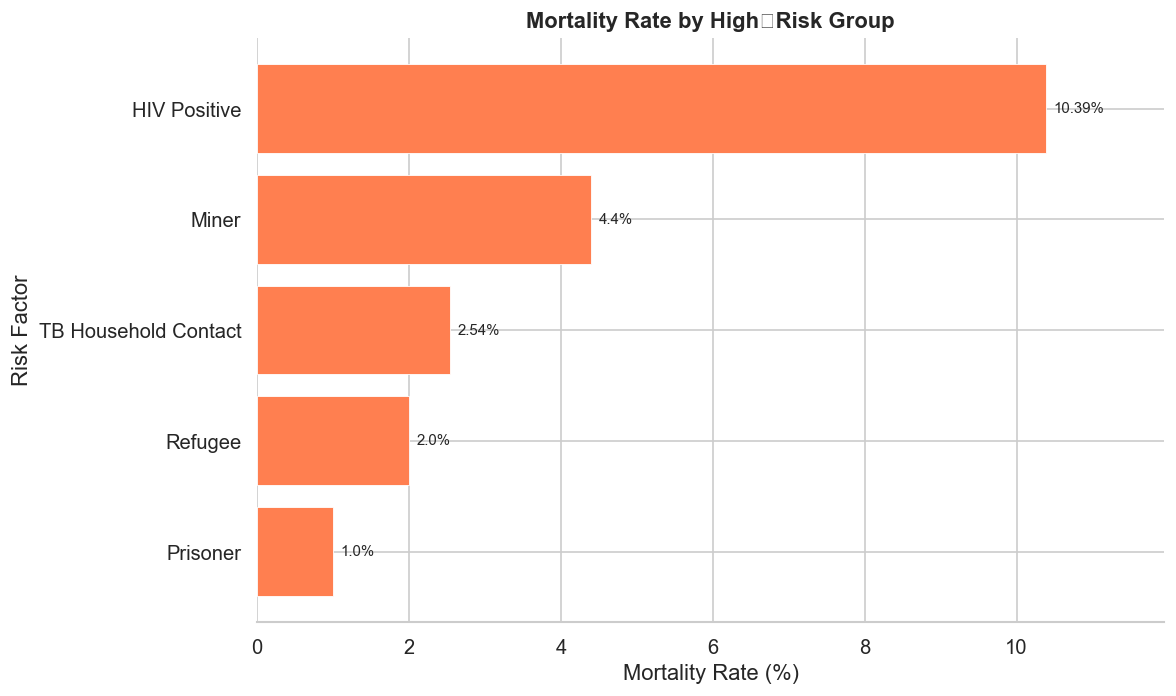

In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 8.2 — CLINICAL SEVERITY & MORTALITY (UPDATED: BMI REMOVED)
# ════════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("SECTION 8.2 — CLINICAL SEVERITY & MORTALITY")
print("="*70)

# Colors
CORAL = "#ff7f50"

# ----------------------------------------------------------------------
# NOTE: BMI category data (bmi_cat_start) is completely missing (all NaN).
# Therefore, the nutritional severity proxy is skipped entirely.
# ----------------------------------------------------------------------
print("\n⚠️ BMI category data is not available (all values missing).")
print("   Skipping nutritional severity proxy.\n")

# ----------------------------------------------------------------------
# Mortality among high‑risk groups
# ----------------------------------------------------------------------
if 'died' in df.columns:
    total_died = df['died'].sum()
    print(f"▶ Total deaths recorded: {total_died:,} ({total_died/len(df)*100:.2f}%)")

    # Risk factor mapping (same as before)
    risk_mapping = {
        'Prisoner': ('prisoners', None),
        'Miner': ('miner', None),
        'Refugee': ('refugee', None),
        'HIV Positive': ('hiv_pos', None),
        'TB Household Contact': ('contact_tb_pos', None),
        'Malnourished': ('bmi_cat_start', lambda x: pd.notna(x) and str(x).lower() == 'underweight')
    }

    mortality_data = []
    for risk, (col, condition) in risk_mapping.items():
        if col not in df.columns:
            continue
        
        # Build mask for risk group
        if condition is None:
            if pd.api.types.is_numeric_dtype(df[col]):
                risk_mask = df[col] > 0
            else:
                risk_mask = df[col].astype(str).str.lower().str.contains('yes|1|true', na=False)
        else:
            risk_mask = df[col].apply(condition)
        
        risk_cases = df[risk_mask]
        if len(risk_cases) > 0:
            died_risk = risk_cases['died'].sum()
            mortality_rate = (died_risk / len(risk_cases) * 100).round(2)
            mortality_data.append({
                'Risk Factor': risk,
                'Cases in Risk Group': len(risk_cases),
                'Deaths': died_risk,
                'Mortality Rate (%)': mortality_rate
            })

    if mortality_data:
        mortality_df = pd.DataFrame(mortality_data).sort_values('Mortality Rate (%)', ascending=False)
        print("\n▶ Mortality Rate by High‑Risk Group:")
        print(mortality_df.to_string(index=False))

        # Horizontal bar chart
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(mortality_df['Risk Factor'][::-1], mortality_df['Mortality Rate (%)'][::-1],
                       color=CORAL, edgecolor='white', linewidth=0.5)
        for bar, rate in zip(bars, mortality_df['Mortality Rate (%)'][::-1]):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f"{rate}%", va='center', ha='left', fontsize=9)
        ax.set_xlim(0, mortality_df['Mortality Rate (%)'].max() * 1.15)
        ax.set_title('Mortality Rate by High‑Risk Group', fontweight='bold')
        ax.set_xlabel('Mortality Rate (%)')
        ax.set_ylabel('Risk Factor')
        sns.despine(left=True)
        plt.tight_layout()
        plt.savefig('fig_8_2_mortality_by_risk.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print("No risk group data available for mortality analysis.")
else:
    print("Column 'died' not found. Skipping mortality analysis.")

In [13]:
print(df['miner'].value_counts(dropna=False))

miner
No         8447
Yes          91
Unknown       2
Name: count, dtype: int64


# ════════════════════════════════════════════════════════════════════════════════
# CELL 9.1 — Prepare GeoJSON and district population data (if available)
# ════════════════════════════════════════════════════════════════════════════════


In [29]:

print("SECTION 9 — GEOSPATIAL ANALYSIS")

# ----------------------------------------------------------------------
# Check if district column exists in the dataset
# ----------------------------------------------------------------------
if 'district' not in df.columns:
    print(" Column 'district' not found in the data. Geospatial analysis skipped.")
    has_district_data = False
else:
    has_district_data = True
    print(f"✓ Found 'district' column with {df['district'].nunique()} unique districts.")

# ----------------------------------------------------------------------
# Try to load Rwanda district GeoJSON file (if available)
# ----------------------------------------------------------------------
geojson_path = 'rwanda_districts.geojson'
has_geojson = False
districts_geojson = None

if has_district_data:
    try:
        import json
        with open(geojson_path, 'r') as f:
            districts_geojson = json.load(f)
        has_geojson = True
        print("✓ GeoJSON file loaded successfully.")
        
        # Optional: inspect property names to know which field contains district name
        sample_feature = districts_geojson['features'][0]
        print(f"   Sample GeoJSON properties: {list(sample_feature['properties'].keys())}")
        
    except FileNotFoundError:
        print(" GeoJSON file 'rwanda_districts.geojson' not found.")
        print("   Maps will be replaced by bar charts.")
    except json.JSONDecodeError:
        print(" GeoJSON file is malformed (invalid JSON).")
        print("   Maps will be replaced by bar charts.")
else:
    print("Skipping GeoJSON load because district column is missing.")

# ----------------------------------------------------------------------
# Population data (for incidence rates per 100,000)
# ----------------------------------------------------------------------
print("\n▶ Population data:")
if has_district_data:
    # Check if any population column exists (not in your column list)
    pop_columns = [col for col in df.columns if 'pop' in col.lower() or 'population' in col.lower()]
    if pop_columns:
        print(f"   Found population-related column(s): {pop_columns}")
        print("   → Will attempt to calculate incidence rates per 100,000.")
        has_population = True
    else:
        print(" No population data found in the dataset.")
        print("   → Only raw TB case counts can be mapped, not incidence rates.")
        has_population = False
else:
    has_population = False

# ----------------------------------------------------------------------
# Aggregate TB cases by district (for later mapping)
# ----------------------------------------------------------------------
if has_district_data:
    district_counts = df['district'].value_counts().reset_index()
    district_counts.columns = ['district', 'tb_cases']
    print(f"\n▶ Top 5 districts by TB case count:")
    print(district_counts.head().to_string(index=False))
    
    # Optional: save aggregated data for later use
    # district_counts.to_csv('district_tb_cases.csv', index=False)
else:
    district_counts = None

print("Ready for geospatial visualization .")


SECTION 9 — GEOSPATIAL ANALYSIS
✓ Found 'district' column with 30 unique districts.
 GeoJSON file 'rwanda_districts.geojson' not found.
   Maps will be replaced by bar charts.

▶ Population data:
 No population data found in the dataset.
   → Only raw TB case counts can be mapped, not incidence rates.

▶ Top 5 districts by TB case count:
           district  tb_cases
Nyarugenge District       903
 Rwamagana District       771
    Gasabo District       738
    Rubavu District       736
  Kicukiro District       686
Ready for geospatial visualization .


In [19]:
import json

# File path
geojson_path = r"C:\Users\USER\Desktop\TB-DEEP-ANALYSIS\geoBoundaries-RWA-ADM2_simplified.geojson"

# Read GeoJSON file
with open(geojson_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Display basic information
print("GeoJSON loaded successfully!")
print("Number of features:", len(data['features']))

# Display first feature
first_feature = data['features'][0]

print("\nFirst feature properties:")
print(first_feature['properties'])

print("\nFirst feature geometry type:")
print(first_feature['geometry']['type'])

GeoJSON loaded successfully!
Number of features: 30

First feature properties:
{'shapeName': 'Nyarugenge', 'shapeISO': '', 'shapeID': '39286606B91255837333217', 'shapeGroup': 'RWA', 'shapeType': 'ADM2'}

First feature geometry type:
Polygon


In [22]:
# Your dataset's districts
data_districts = df['district'].unique()
print("Sample from your data:", sorted(data_districts)[:5])

# GeoJSON districts
geo_districts = [feat['properties']['shapeName'] for feat in geojson_data['features']]
print("Sample from GeoJSON:", sorted(geo_districts)[:5])

Sample from your data: ['Bugesera District', 'Burera District', 'Gakenke District', 'Gasabo District', 'Gatsibo District']
Sample from GeoJSON: ['Bugesera', 'Burera', 'Gakenke', 'Gasabo', 'Gatsibo']


# ════════════════════════════════════════════════════════════════════════════════
# CELL 9.2 — Choropleth Map of TB Cases by District (Rwanda)
# ════════════════════════════════════════════════════════════════════════════════

In [30]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 1. Load GeoJSON from your specific path
# ----------------------------------------------------------------------
geojson_path = r"C:\Users\USER\Desktop\TB-DEEP-ANALYSIS\geoBoundaries-RWA-ADM2_simplified.geojson"

try:
    with open(geojson_path, 'r', encoding='utf-8') as f:
        geojson = json.load(f)
    print(f"  Number of districts in GeoJSON: {len(geojson['features'])}")
except FileNotFoundError:
    print(f"✗ GeoJSON file not found at: {geojson_path}")
    raise

# ----------------------------------------------------------------------
# 2. Get district names from GeoJSON (property 'shapeName')
# ----------------------------------------------------------------------
geo_districts = [feat['properties']['shapeName'] for feat in geojson['features']]
print(f"  First 5 GeoJSON districts: {geo_districts[:5]}")

# ----------------------------------------------------------------------
# 3. Aggregate TB cases from your dataframe by district
# ----------------------------------------------------------------------
if 'district' not in df.columns:
    raise KeyError("Column 'district' not found in dataframe.")

district_counts = df['district'].value_counts().reset_index()
district_counts.columns = ['district', 'tb_cases']
print(f"  Number of districts in data: {len(district_counts)}")
print(f"  First 5 data districts: {district_counts['district'].head().tolist()}")

# ----------------------------------------------------------------------
# 4. Match district names (remove ' District' suffix)
# ----------------------------------------------------------------------
def normalize(name):
    """Remove ' District' and strip spaces, but keep case for display."""
    if not isinstance(name, str):
        return ''
    return name.replace(' District', '').strip()

# Create mapping from data district name to GeoJSON district name
name_mapping = {}
unmatched = []
for data_name in district_counts['district'].unique():
    norm_data = normalize(data_name)
    match = None
    for geo_name in geo_districts:
        if geo_name.lower() == norm_data.lower():
            match = geo_name
            break
    if match:
        name_mapping[data_name] = match
    else:
        unmatched.append(data_name)

if unmatched:
    print(f" Warning: {len(unmatched)} district(s) could not be matched:")
    print(unmatched)
else:
    print(f" Successfully matched all {len(name_mapping)} districts.")

# Add a column with GeoJSON-compatible district name
district_counts['geojson_name'] = district_counts['district'].map(name_mapping)
district_counts = district_counts.dropna(subset=['geojson_name']).copy()

# ----------------------------------------------------------------------
# 5. Create interactive choropleth map (Plotly required)
# ----------------------------------------------------------------------
try:
    import plotly.express as px
    has_plotly = True
except ImportError:
    has_plotly = False
    print("\n Plotly not installed. Install with: pip install plotly")
    print("Falling back to static bar chart.\n")

if has_plotly and len(district_counts) > 0:
    # Add tb_cases to GeoJSON properties (for hover)
    for feature in geojson['features']:
        geo_name = feature['properties']['shapeName']
        match = district_counts[district_counts['geojson_name'] == geo_name]
        if len(match) > 0:
            feature['properties']['tb_cases'] = int(match.iloc[0]['tb_cases'])
        else:
            feature['properties']['tb_cases'] = 0  # district in GeoJSON but no TB cases

    fig = px.choropleth_mapbox(
        district_counts,
        geojson=geojson,
        locations='geojson_name',
        featureidkey="properties.shapeName",
        color='tb_cases',
        color_continuous_scale="Reds",
        range_color=(0, district_counts['tb_cases'].max()),
        mapbox_style="carto-positron",
        zoom=8,
        center={"lat": -2.0, "lon": 30.0},
        opacity=0.7,
        labels={'tb_cases': 'Number of TB Cases'},
        hover_name='district',
        hover_data={'geojson_name': False, 'tb_cases': True}
    )
    fig.update_layout(
        title_text="TB Cases by District, Rwanda (Treatment Cohort)",
        title_x=0.5,
        margin={"r":0, "t":40, "l":0, "b":0},
        coloraxis_colorbar=dict(title="TB Cases")
    )
    fig.show()
    fig.write_html("tb_cases_map.html")
    print("Interactive map saved as 'tb_cases_map.html'")
else:
    # Fallback: horizontal bar chart of top districts
    print("Creating horizontal bar chart (Plotly not available or no matched districts).")
    top_n = 15
    top_districts = district_counts.nlargest(top_n, 'tb_cases')[::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top_districts['district'], top_districts['tb_cases'], color='#d73027')
    ax.set_xlabel('Number of TB Cases')
    ax.set_title(f'Top {top_n} Districts by TB Case Count', fontweight='bold')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(left=True)
    plt.tight_layout()
    plt.savefig('fig_9_2_district_bar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

  Number of districts in GeoJSON: 30
  First 5 GeoJSON districts: ['Nyarugenge', 'Gasabo', 'Kicukiro', 'Nyanza', 'Gisagara']
  Number of districts in data: 30
  First 5 data districts: ['Nyarugenge District', 'Rwamagana District', 'Gasabo District', 'Rubavu District', 'Kicukiro District']
 Successfully matched all 30 districts.


Interactive map saved as 'tb_cases_map.html'


In [21]:
import pandas as pd

# Extract district names
districts = [feature['properties']['shapeName'] for feature in data['features']]

# Create DataFrame
df_geo = pd.DataFrame(districts, columns=['district_name'])

# Display
df_geo.head(10)

,district_name
0,Nyarugenge
1,Gasabo
2,Kicukiro
3,Nyanza
4,Gisagara
5,Nyaruguru
6,Huye
7,Nyamagabe
8,Ruhango
9,Muhanga


# ════════════════════════════════════════════════════════════════════════════════
# CELL 9.3 — Province‑Level Aggregation and Maps (if province data available)
# ════════════════════════════════════════════════════════════════════════════════


In [32]:
# Create province column from district names (Rwanda districts)
# Based on the official administrative structure of Rwanda

district_to_province = {
    # Kigali City
    'Nyarugenge': 'Kigali City',
    'Gasabo': 'Kigali City',
    'Kicukiro': 'Kigali City',
    
    # Eastern Province
    'Bugesera': 'Eastern',
    'Gatsibo': 'Eastern',
    'Kayonza': 'Eastern',
    'Kirehe': 'Eastern',
    'Ngoma': 'Eastern',
    'Nyagatare': 'Eastern',
    'Rwamagana': 'Eastern',
    
    # Western Province
    'Karongi': 'Western',
    'Ngororero': 'Western',
    'Nyabihu': 'Western',
    'Nyamasheke': 'Western',
    'Rubavu': 'Western',
    'Rusizi': 'Western',
    'Rutsiro': 'Western',
    
    # Northern Province
    'Burera': 'Northern',
    'Gakenke': 'Northern',
    'Gicumbi': 'Northern',
    'Musanze': 'Northern',
    'Rulindo': 'Northern',
    
    # Southern Province
    'Gisagara': 'Southern',
    'Huye': 'Southern',
    'Kamonyi': 'Southern',
    'Muhanga': 'Southern',
    'Nyamagabe': 'Southern',
    'Nyanza': 'Southern',
    'Nyaruguru': 'Southern',
    'Ruhango': 'Southern',
}

# Clean district names (remove ' District' suffix) and map to province
def map_district_to_province(district_name):
    if not isinstance(district_name, str):
        return None
    # Remove ' District' suffix
    base_name = district_name.replace(' District', '').strip()
    return district_to_province.get(base_name)

df['province'] = df['district'].apply(map_district_to_province)

# Check the mapping result
print("Province column created. Value counts:")
print(df['province'].value_counts(dropna=False))

Province column created. Value counts:
province
Kigali City    2327
Eastern        2048
Southern       1814
Western        1526
Northern        825
Name: count, dtype: int64


In [37]:
print(df['treatment_outcome'].value_counts())
print(df['drug_sensitivity'].value_counts())

treatment_outcome
Unknown              3860
Cured                2636
Completed            1397
Died                  404
Lost to follow-up     164
Not evaluated          51
Failure                28
Name: count, dtype: int64
drug_sensitivity
DS-TB    8448
DR-TB      92
Name: count, dtype: int64



▶ Province‑level aggregated data:


,province,Total Cases,Success Rate (%),DR-TB Proportion (%)
0,Eastern,2048,52.2,1.3
1,Kigali City,2327,43.6,1.2
2,Northern,825,48.8,0.8
3,Southern,1814,55.2,0.7
4,Western,1526,35.7,1.1



▶ Province‑level bar charts:


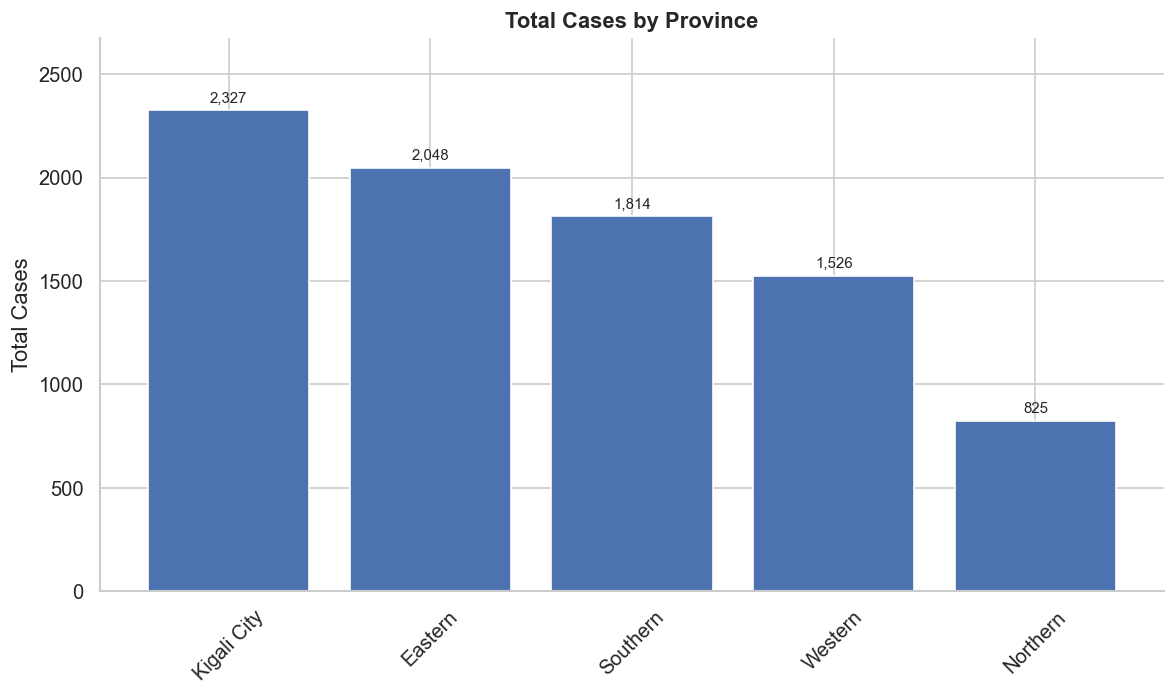

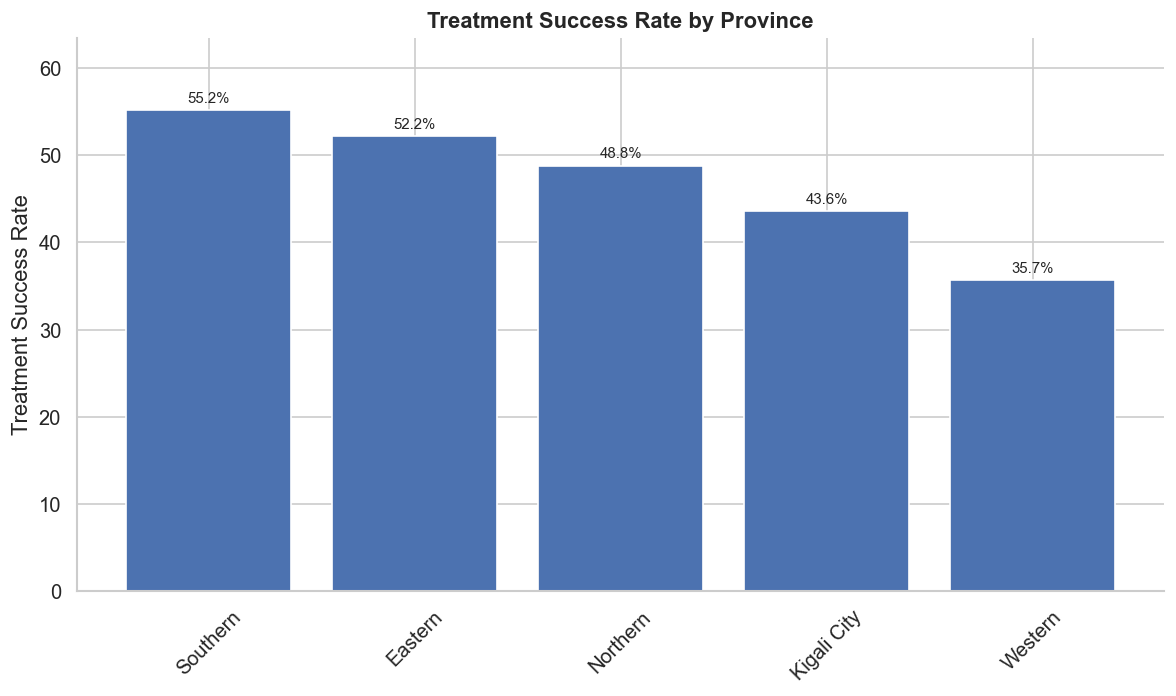

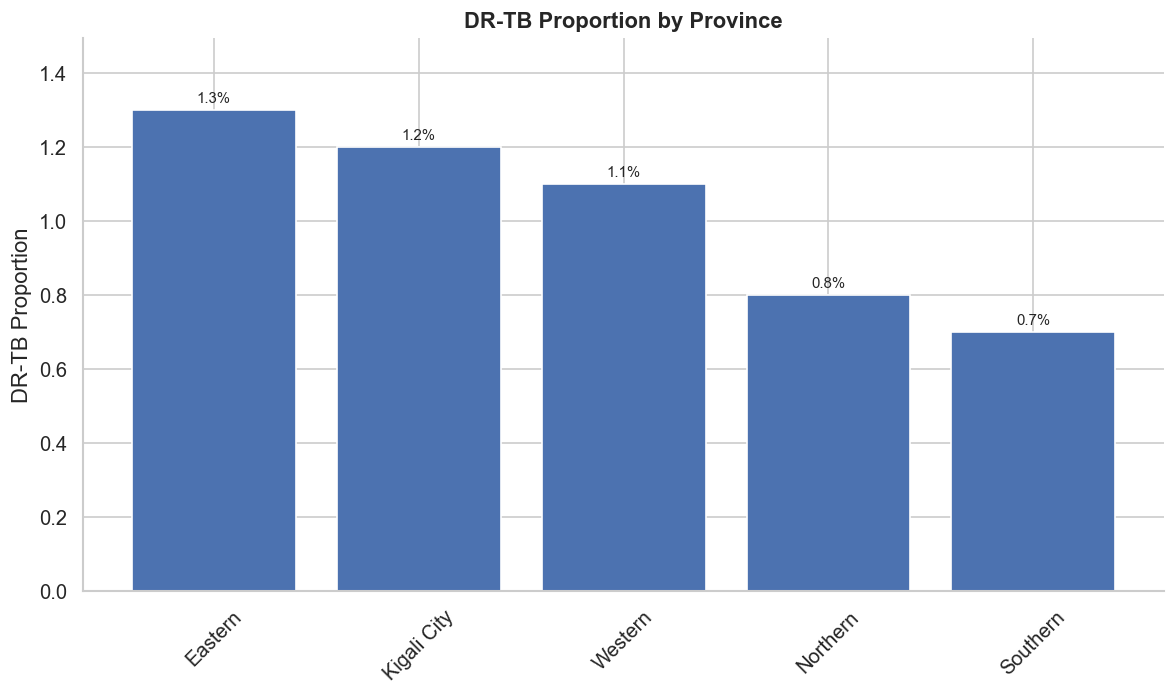

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'province' in df.columns:
    BLUE = "#4c72b0"
    
    # 1. Total cases by province
    total_by_province = df.groupby('province').size().reset_index(name='Total Cases')
    
    # 2. Treatment success rate by province (Cured + Completed)
    if 'treatment_outcome' in df.columns:
        success_mask = df['treatment_outcome'].isin(['Cured', 'Completed'])
        success_by_province = df[success_mask].groupby('province').size().reset_index(name='Success')
        total_by_province2 = df.groupby('province').size().reset_index(name='Total')
        success_rate_prov = success_by_province.merge(total_by_province2, on='province', how='right').fillna(0)
        success_rate_prov['Success Rate (%)'] = (success_rate_prov['Success'] / success_rate_prov['Total'] * 100).round(1)
        success_rate_prov = success_rate_prov[['province', 'Success Rate (%)']]
    else:
        success_rate_prov = None
    
    # 3. DR-TB proportion by province (exact 'DR-TB')
    if 'drug_sensitivity' in df.columns:
        dr_mask = df['drug_sensitivity'] == 'DR-TB'
        dr_by_province = df[dr_mask].groupby('province').size().reset_index(name='DR_Cases')
        if 'total_by_province2' not in locals():
            total_by_province2 = df.groupby('province').size().reset_index(name='Total')
        dr_prop_prov = dr_by_province.merge(total_by_province2, on='province', how='right').fillna(0)
        dr_prop_prov['DR-TB Proportion (%)'] = (dr_prop_prov['DR_Cases'] / dr_prop_prov['Total'] * 100).round(1)
        dr_prop_prov = dr_prop_prov[['province', 'DR-TB Proportion (%)']]
    else:
        dr_prop_prov = None
    
    # Merge
    prov_map_data = total_by_province
    if success_rate_prov is not None:
        prov_map_data = prov_map_data.merge(success_rate_prov, on='province', how='left')
    if dr_prop_prov is not None:
        prov_map_data = prov_map_data.merge(dr_prop_prov, on='province', how='left')
    
    print("\n▶ Province‑level aggregated data:")
    from IPython.display import display
    display(prov_map_data)
    
    print("\n▶ Province‑level bar charts:")
    indicators = [
        ('Total Cases', 'Total Cases', False),
        ('Success Rate (%)', 'Treatment Success Rate', True),
        ('DR-TB Proportion (%)', 'DR-TB Proportion', True)
    ]
    
    for col_name, title, is_percent in indicators:
        if col_name in prov_map_data.columns:
            fig, ax = plt.subplots(figsize=(10, 6))
            prov_sorted = prov_map_data.sort_values(col_name, ascending=False)
            bars = ax.bar(prov_sorted['province'], prov_sorted[col_name],
                          color=BLUE, edgecolor='white')
            for bar, val in zip(bars, prov_sorted[col_name]):
                if col_name == 'Total Cases':
                    label = f"{int(val):,}"
                else:
                    label = f"{val:.1f}%" if is_percent else f"{val:.1f}"
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + prov_sorted[col_name].max()*0.01,
                        label, ha='center', va='bottom', fontsize=9)
            ax.set_ylim(0, prov_sorted[col_name].max() * 1.15)
            ax.set_title(f'{title} by Province', fontweight='bold')
            ax.set_ylabel(title)
            ax.tick_params(axis='x', rotation=45)
            sns.despine()
            plt.tight_layout()
            plt.savefig(f'fig_9_3_province_{col_name.replace(" ", "_")}.png', bbox_inches='tight', dpi=150)
            plt.show()
else:
    print(" Province column not found. Please create it using district-to-province mapping.")